## Load Packages

In [10]:
import scipy
import numpy as np
import xarray as xr
import pandas as pd

from dissipationIFR.config import plotting_style, VMP_variables
from dissipationIFR import utilities, tools
#plotting_style = "/Users/u302042/Desktop/DissipationIFR/dissipationIFR/dissipationIFR/config/plotting.mplstyle"

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker

import os

## 1. Converting VMP data to netCDF format

In [3]:
path = "/Users/u302042/Desktop/Master_thesis/Data/VMP/"
file = "ALLMERGED.mat"
data = scipy.io.loadmat(path + file)

In [4]:
ds_VMP = utilities.create_vmp_dataset(data, VMP_variables)

In [5]:
savefile = "All_VMP.nc"
delete_existing = False  # Set to True to delete existing file, False to keep it
### check if file already exists and delete it if it does
if os.path.exists(path + savefile):
    if delete_existing:
        os.remove(path + savefile)
        print(f"Deleted existing file: {path + savefile}\n Saving new file...")
        ds_VMP.to_netcdf(path + savefile)
    else:
        print(f"File already exists: {path + savefile}. Not deleting.")
else:
    print(f"Saving new file: {path + savefile}...")
    ds_VMP.to_netcdf(path + savefile)
    

File already exists: /Users/u302042/Desktop/Master_thesis/Data/VMP/All_VMP.nc. Not deleting.


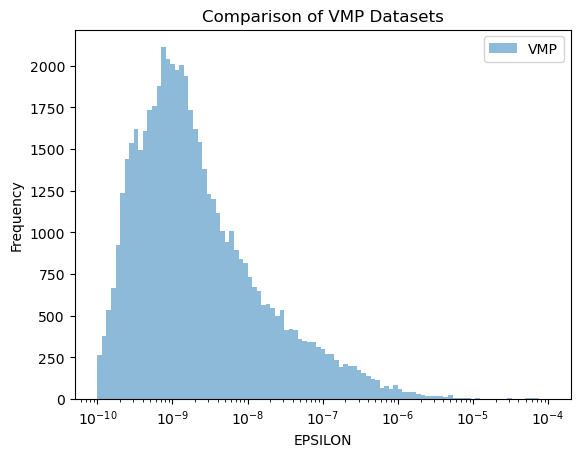

In [6]:
bins = np.logspace(-10, -4, 100)  # Define logarithmically spaced bins
plt.hist(ds_VMP['EPSILON'].values.flatten(), bins=bins, alpha=0.5, label='VMP')
plt.xlabel('EPSILON')
plt.ylabel('Frequency')
plt.title('Comparison of VMP Datasets')
plt.legend()
plt.xscale('log')
plt.show()

## 2. Open sg005 data and cut it to region of VMP casts

In [24]:
sg005_path = "/Users/u302042/Desktop/Master_thesis/Data/Glider/005/20080606/"
sg005_file = "gridded_ownfm.nc"
#sg005_file = "gridded_bs3.nc"
glider = xr.open_dataset(sg005_path + sg005_file)
### add cast number to sg005 dataset, always two profiles are one cast (e.g profile 1 and 2 are cast 1)
glider['CAST'] = (np.ceil(glider.PROFILE_NUMBER/2)).astype(int)

VMP = xr.open_dataset(path + savefile)

In [25]:
# load bathymetry for bottom depth and plotting
bathymetry = xr.open_dataset("/Users/u302042/Desktop/Master_thesis/Data/Bathymetry/GEBCO_2024_IFR.nc")

for ds in [VMP, glider]:
    dims = list(ds.sizes.keys())[0]
    lon, lat = ds.LONGITUDE, ds.LATITUDE
    elevation = bathymetry['elevation'].sel(lon=lon, lat=lat, method='nearest')
    ds['BATHYMETRY'] = elevation
    depth = ds.DEPTH
    ds['HEIGHT_ABOVE_BOTTOM'] = -(depth + elevation)

In [26]:
# Apply glider mask for better comparison with VMP data
excluded_casts = [93, 146, 75, 76, 85, 187, 188, 189, 190]
glider_mask = ((glider.LATITUDE.values > 60) & (glider.LATITUDE.values < 61.98)
    & (glider.TIME.values >= np.datetime64("2008-06-06T20:00")) & (glider.TIME.values <= np.datetime64("2008-07-22T10:00"))
    & (~glider.CAST.isin(excluded_casts))
)
glider = glider.sel(N_MEASUREMENTS=glider_mask)

# Remove the first sixteen VMP profiles and keep only deep measurements
vmp_mask = ((VMP.PROFILE_NUMBER.values >= 16) & (VMP.BATHYMETRY.values <= -700))
VMP = VMP.sel(N_MEASUREMENTS=vmp_mask)


[   0.  100.  200.  300.  400.  500.  600.  700.  800.  900. 1000. 1100.
 1200. 1300. 1400.]


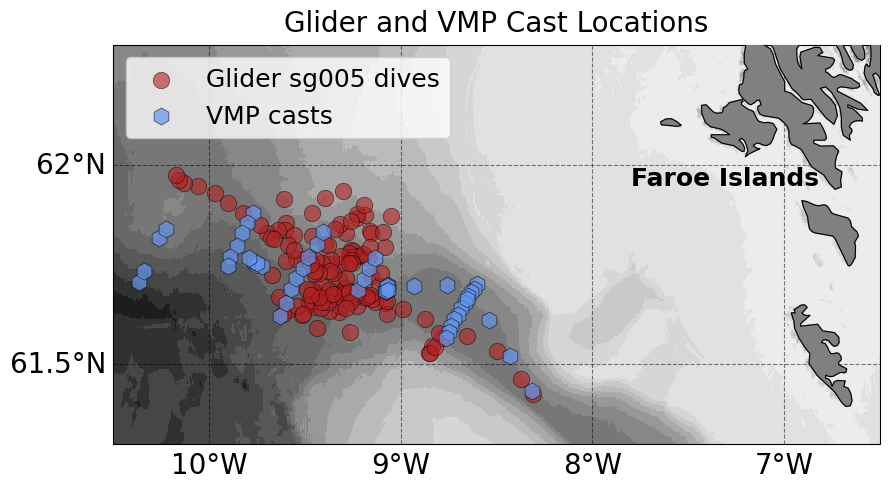

In [30]:
latitudes = glider.LATITUDE.groupby(glider.CAST).mean().values
longitudes = glider.LONGITUDE.groupby(glider.CAST).mean().values
times = glider.TIME.groupby(glider.CAST).mean().values
profile_numbers = glider.CAST.groupby(glider.CAST).mean().values

 # Data to plot
VMP_lat = VMP.LATITUDE.groupby(VMP.PROFILE_NUMBER).mean().values
VMP_lon = VMP.LONGITUDE.groupby(VMP.PROFILE_NUMBER).mean().values

# Set the colorbar mode: either 'TIME' or 'PROFILES'
#color_mode = 'TIME'

map_kw = ccrs.PlateCarree()
# Prepare figure and axis
with plt.style.context(plotting_style):
    fig, ax = plt.subplots(subplot_kw={"projection": map_kw}, figsize=(9, 5))

    # Bounding box
    lon_min, lon_max = -10.5, -6.5
    lat_min, lat_max = 61.3, 62.3
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=map_kw)
    ax.set_aspect("auto")

    # Bathymetry background
    bath = bathymetry.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))
    levels, contour_levels, max_level = tools.get_bathymetry_levels(bath,level_spacing=100)
    print(levels)
    base_cmap = plt.get_cmap("Greys")
    cmap_bath = mcolors.LinearSegmentedColormap.from_list("dark_greys", base_cmap(np.linspace(0.15, 0.9, len(levels))))
    norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap_bath.N)
    ax.pcolormesh(
        bath.lon, bath.lat, abs(bath.elevation.values),
        cmap=cmap_bath, norm=norm, transform=ccrs.PlateCarree(), zorder=1
    )

    # Glider scatter
    ax.scatter(
        longitudes, latitudes,alpha=0.6,
        color="firebrick", s=140, marker='o', label="Glider sg005 dives", edgecolors="black", linewidths=0.5
    )

    ax.scatter(
        VMP_lon, VMP_lat,alpha=0.7,
        color="cornflowerblue", s=150, marker='h', label="VMP casts", edgecolors="black", linewidths=0.5
    )

    # Final plot settings
    ax.legend(loc='upper left', fontsize=18)

    ax.add_feature(cfeature.LAND, color="gray", zorder=10)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=11)

    # Gridlines
    gl = ax.gridlines(draw_labels=True, color="black", alpha=0.5, linestyle="--")
    gl.xlocator = mticker.FixedLocator([-11, -10, -9 , -8,-7, -6])
    gl.ylocator = mticker.FixedLocator([61.5, 62])
    #### make ticks bigger
    gl.xlabel_style = {'size': 20}
    gl.ylabel_style = {'size': 20}
    gl.top_labels = False
    gl.right_labels = False

    ax.text(x=-7.8, y=61.95, s="Faroe Islands", fontsize= 18,weight='bold',zorder = 100)

plt.title("Glider and VMP Cast Locations", fontsize=20, pad = 10)
plt.tight_layout()
plt.grid()
plt.show()

## 3. Compare VMP and sg005 data for different layers

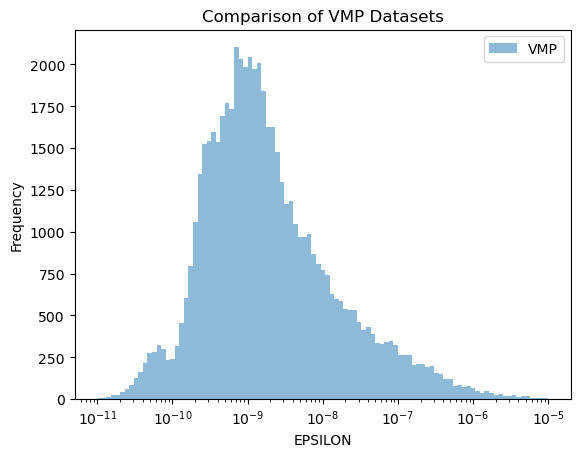

In [71]:
bins = np.logspace(-11, -5, 100)  # Define logarithmically spaced bins
#percentage = True
#if percentage:
#    weights = np.ones_like(ds_VMP['EPSILON'].values.flatten()) / len(ds_VMP['EPSILON'].values.flatten())
plt.hist(VMP['EPSILON'].values.flatten(), bins=bins, alpha=0.5, label='VMP')
#plt.hist(glider['EPSILON_330'].values.flatten(), bins=bins, alpha=0.5, label='SG005 Constant')
#plt.hist(glider['EPSILON_ADAPTIVE'].values.flatten(), bins=bins, alpha=0.5, label='SG005 Adaptive')
plt.xlabel('EPSILON')
plt.ylabel('Frequency')
plt.title('Comparison of VMP Datasets')
plt.legend()
plt.xscale('log')
plt.show()